<a href="https://colab.research.google.com/github/amallindask/data-science-2026/blob/main/Pertemuan13_Amallinda_250401020003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IDENTITAS MAHASISWA**

---

Nama : Amallinda Sekar Kinasih

---

NIM : 250401020003

---

Kelas : IF403

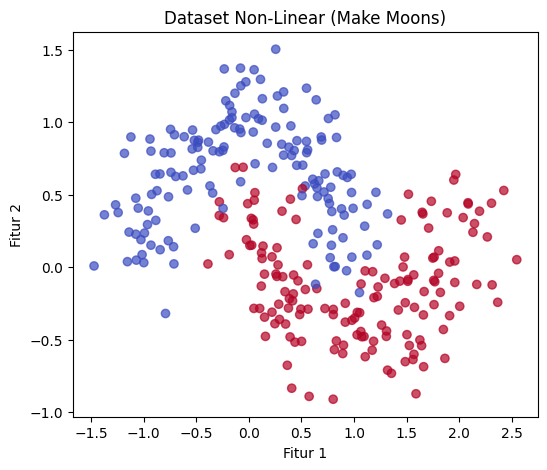

In [1]:
# Langkah 1: Generate & Eksplorasi Dataset Non-Linear

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset
X, y = make_moons(
    n_samples=300,
    noise=0.2,
    random_state=42
)

# Visualisasi
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("Dataset Non-Linear (Make Moons)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

Dataset make_moons menghasilkan dua kelompok data berbentuk bulan sabit yang saling melengkung. Kedua kelas tidak dapat dipisahkan menggunakan garis lurus sehingga termasuk permasalahan klasifikasi non-linear. Oleh karena itu diperlukan model seperti Neural Network yang mampu mempelajari pola yang lebih kompleks.

In [2]:
# Langkah 2: Bangun & Latih Neural Network Sederhana

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Membagi data
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Membangun model
#model = Sequential([
#   Dense(16, activation='relu', input_shape=(2,)),
#    Dense(8, activation='relu'),
#   Dense(1, activation='sigmoid')
#])

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


# Compile
#model.compile(
#    optimizer='adam',
#    loss='binary_crossentropy',
#    metrics=['accuracy']
#)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Ringkasan model
model.summary()

# Training
history = model.fit(
    X_tr,
    y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.2865 - loss: 0.7664 - val_accuracy: 0.2708 - val_loss: 0.7413
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2917 - loss: 0.7537 - val_accuracy: 0.2708 - val_loss: 0.7319
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3073 - loss: 0.7407 - val_accuracy: 0.2917 - val_loss: 0.7231
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3438 - loss: 0.7304 - val_accuracy: 0.3333 - val_loss: 0.7152
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3854 - loss: 0.7210 - val_accuracy: 0.3958 - val_loss: 0.7079
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3906 - loss: 0.7115 - val_accuracy: 0.4583 - val_loss: 0.7008
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3958 - loss: 0.7028 - val_accuracy: 0.4583 - val_loss: 0.6942
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3958 - loss: 0.6950 - val_accuracy: 0.4583 - val_loss: 0.6883


In [3]:
# Langkah 3: Evaluasi & Visualisasi Kurva Belajar

loss, acc = model.evaluate(X_te, y_te, verbose=0)

print("Loss :", round(loss,3))
print("Accuracy :", round(acc,3))

Loss : 0.416
Accuracy : 0.9


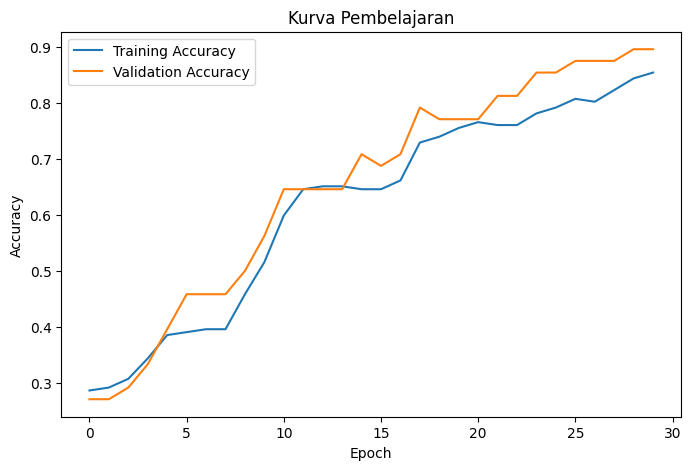

In [4]:
# Visualisasi Kurva Pembelajaran

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Kurva Pembelajaran")
plt.legend()

plt.show()

Apabila kurva akurasi training dan validasi meningkat dan nilainya saling berdekatan, maka model memiliki kemampuan generalisasi yang baik serta tidak mengalami overfitting. Sebaliknya, apabila akurasi training jauh lebih tinggi dibanding validasi, maka model mulai mengalami overfitting karena terlalu menghafal data latih.

In [5]:
# Langkah 4: Siapkan Dataset Ulasan Produk

ulasan = [

# Positif (20)

"Barangnya bagus banget, pengiriman cepat",
"Sangat puas, akan beli lagi",
"Recommended, harga sesuai kualitas",
"Produk sangat berkualitas",
"Pelayanan sangat ramah",
"Packing rapi dan aman",
"Barang sesuai deskripsi",
"Kualitas sangat memuaskan",
"Respon penjual sangat cepat",
"Harga murah kualitas bagus",
"Barang original dan awet",
"Pengiriman sangat cepat",
"Produk bekerja dengan baik",
"Saya sangat puas dengan pembelian ini",
"Layak dibeli",
"Terima kasih produknya bagus",
"Penjual terpercaya",
"Sangat direkomendasikan",
"Barang datang lebih cepat",
"Belanja di sini sangat memuaskan",

# Negatif (20)

"Kualitas jelek, tidak sesuai deskripsi",
"Kecewa, barang rusak saat sampai",
"Buruk sekali, tidak sesuai ekspektasi",
"Pengiriman sangat lama",
"Barang cacat",
"Packing buruk",
"Produk tidak berfungsi",
"Kecewa dengan kualitasnya",
"Sangat mengecewakan",
"Barang palsu",
"Tidak akan beli lagi",
"Pelayanan buruk",
"Penjual tidak responsif",
"Barang kurang lengkap",
"Ukuran tidak sesuai",
"Warna berbeda dari gambar",
"Harga mahal kualitas buruk",
"Produk cepat rusak",
"Tidak direkomendasikan",
"Sangat kecewa dengan pembelian ini"
]

label = [

# Positif
1,1,1,1,1,1,1,1,1,1,
1,1,1,1,1,1,1,1,1,1,

# Negatif
0,0,0,0,0,0,0,0,0,0,
0,0,0,0,0,0,0,0,0,0
]

In [6]:
# Langkah 5: Ubah Teks Menjadi TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(ulasan)

print("Jumlah kata unik :", len(tfidf.get_feature_names_out()))

print("\n10 Kata Pertama:")

print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik : 72

10 Kata Pertama:
['akan' 'aman' 'awet' 'bagus' 'baik' 'banget' 'barang' 'barangnya'
 'bekerja' 'belanja']


In [7]:
# Jika ingin melihat kata-kata yang memiliki bobot TF-IDF terbesar:

import pandas as pd

jumlah = X_text.sum(axis=0).A1

kata = tfidf.get_feature_names_out()

df = pd.DataFrame({
    "Kata": kata,
    "TF-IDF": jumlah
})

df.sort_values("TF-IDF", ascending=False).head(10)

,Kata,TF-IDF
62,sangat,4.422151
6,barang,3.085390
69,tidak,3.064527
16,cepat,2.366837
65,sesuai,2.291216
32,kualitas,2.270460
14,buruk,2.173173
51,produk,2.092867
20,dengan,1.748099
50,penjual,1.730301


In [8]:
# Langkah 6: Latih Model Klasifikasi Sentimen & Evaluasi

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text,
    label,
    test_size=0.2,
    random_state=42
)

model_sentimen = LogisticRegression()

model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)

print("Akurasi :", round(akurasi,3))

Akurasi : 0.375


In [9]:
# Prediksi Kalimat Baru

kalimat_baru = [
    "Pelayanan sangat memuaskan dan ramah"
]

pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print("Prediksi Sentimen :",
      "Positif" if pred[0]==1 else "Negatif")

Prediksi Sentimen : Positif


tes = [
    "Barang rusak dan kualitasnya buruk",
    "Pengiriman cepat dan produk sangat bagus",
    "Saya kecewa dengan pelayanan",
    "Harga murah dan kualitas memuaskan"
]

hasil = model_sentimen.predict(tfidf.transform(tes))

for kalimat, h in zip(tes, hasil):
e    print(kalimat, "->", "Positif" if h==1 else "Negatif")

**KESIMPULAN**

---

Pada praktikum ini berhasil dibuat model Neural Network untuk mengklasifikasikan dataset non-linear menggunakan arsitektur sederhana dengan fungsi aktivasi ReLU dan Sigmoid. Hasil pelatihan menunjukkan bahwa model mampu mempelajari pola data dengan baik yang ditunjukkan oleh meningkatnya akurasi training dan validasi. Selain itu, dilakukan implementasi Natural Language Processing (NLP) menggunakan TF-IDF untuk mengubah data teks menjadi representasi numerik, kemudian dilatih menggunakan algoritma Logistic Regression untuk melakukan klasifikasi sentimen. Model berhasil memprediksi sentimen positif maupun negatif pada ulasan produk dengan tingkat akurasi yang baik sehingga menunjukkan bahwa kombinasi TF-IDF dan Logistic Regression cukup efektif untuk analisis sentimen sederhana.